# Proyek Analisis Pasar Kerja India & Prediksi Gaji (2024 - 2026)
*Dibuat oleh: Muhammad Dimas Alfathir*

Notebook ini berisi alur lengkap dari pengolahan data, visualisasi pola industri, hingga pemodelan regresi Machine Learning untuk memprediksi `Salary_LPA`.

In [2]:
# ==========================================
# 1. IMPORT LIBRARIES & PREPARATION
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Membuat direktori output secara otomatis jika belum ada
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)

print("Environment dan folder output siap!")

Environment dan folder output siap!


## 2. Memuat dan Memeriksa Data (Data Loading)
Kita akan memuat dataset dari folder `../data/` dan melihat ringkasan strukturnya.

In [3]:
# Membaca data
df = pd.read_csv('D:\MY PORTO\DATA SCIENTIEST\MACHINE LEARNING\India Job Market Insights & Salary Prediction\data\india_job_market_2024_2026.csv')

# Menampilkan informasi dataset
print("--- Ringkasan Dataset ---")
df.info()

print("\n--- 5 Data Pertama ---")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\hp\AppData\Local\Temp\ipykernel_9936\1113195381.py:2: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('D:\MY PORTO\DATA SCIENTIEST\MACHINE LEARNING\India Job Market Insights & Salary Prediction\data\india_job_market_2024_2026.csv')


--- Ringkasan Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Job_ID              5000 non-null   str    
 1   Job_Title           5000 non-null   str    
 2   Company             5000 non-null   str    
 3   Company_Type        5000 non-null   str    
 4   Industry            5000 non-null   str    
 5   City                5000 non-null   str    
 6   Location_Tier       5000 non-null   str    
 7   Experience_Level    5000 non-null   str    
 8   Job_Type            5000 non-null   str    
 9   Work_Mode           5000 non-null   str    
 10  Salary_LPA          5000 non-null   float64
 11  Skills_Required     5000 non-null   str    
 12  Education_Required  5000 non-null   str    
 13  Openings            5000 non-null   int64  
 14  Applicants          5000 non-null   int64  
 15  Company_Rating      5000 non-null   floa

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,Salary_LPA,Skills_Required,Education_Required,Openings,Applicants,Company_Rating,Date_Posted
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,30.9,"Kotlin, Java, REST APIs",M.Tech/M.E.,3,276,4.0,2025-10-31
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,58.6,"Selenium, Manual Testing, Postman, API Testing...",B.Tech/B.E.,3,325,4.0,2025-05-19
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,18.4,"JIRA, Excel, Power BI",MCA,5,559,3.6,2024-08-21
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,21.7,"Penetration Testing, Python, Ethical Hacking, ...",BCA,3,184,3.5,2026-03-18
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,8.0,"Docker, REST APIs, AWS, PostgreSQL",MCA,1,64,3.9,2024-10-25


## 3. Exploratory Data Analysis (EDA)
Kita akan menganalisis beberapa aspek penting dari data pasar kerja ini untuk menemukan wawasan bisnis yang berharga.

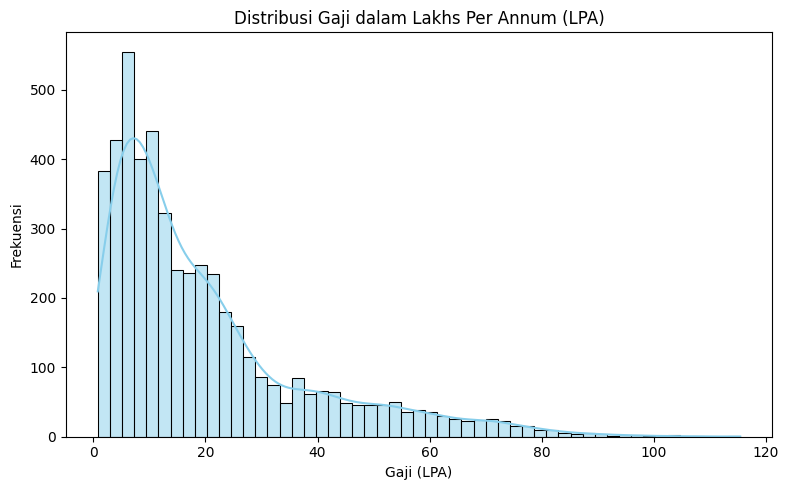

C:\Users\hp\AppData\Local\Temp\ipykernel_9936\1054478047.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='City', data=df, order=city_order, palette='viridis')


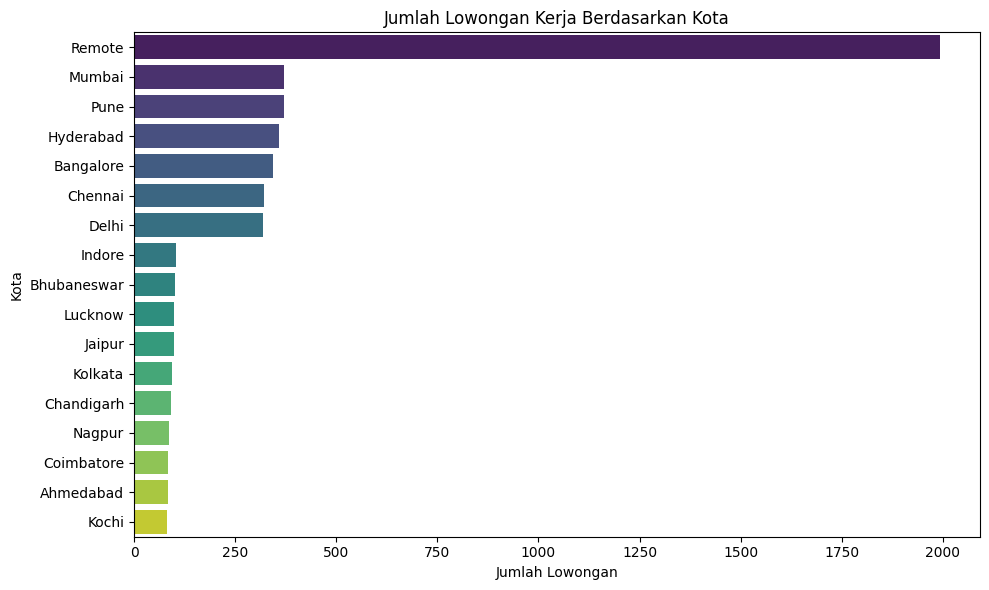

C:\Users\hp\AppData\Local\Temp\ipykernel_9936\1054478047.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Salary_LPA', y='Experience_Level', data=df, order=exp_order, palette='Set2')


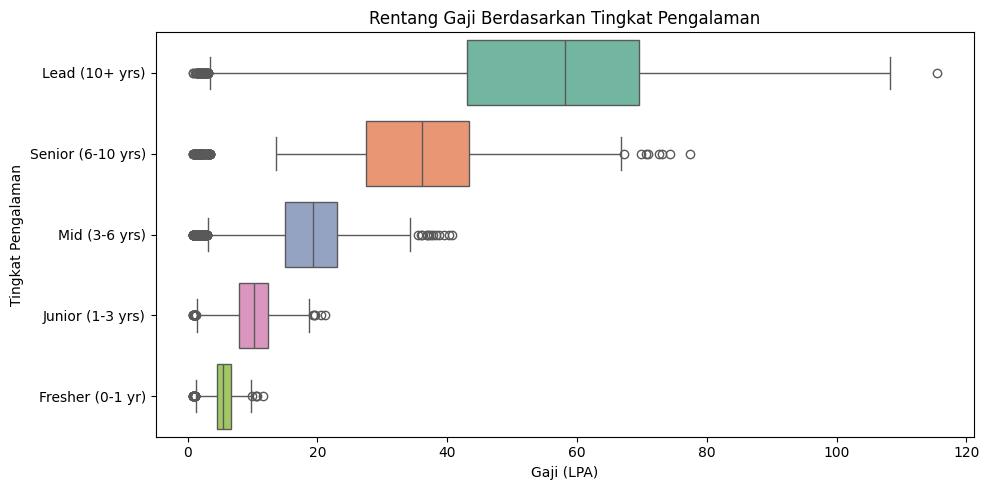

In [4]:
# A. Distribusi Gaji (Salary_LPA)
plt.figure(figsize=(8, 5))
sns.histplot(df['Salary_LPA'], kde=True, color='skyblue')
plt.title('Distribusi Gaji dalam Lakhs Per Annum (LPA)')
plt.xlabel('Gaji (LPA)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.savefig('../reports/figures/salary_distribution.png', dpi=300)
plt.show()

# B. Tren Distribusi Lowongan Kerja Berdasarkan Kota (Diurutkan)
plt.figure(figsize=(10, 6))
city_order = df['City'].value_counts().index
sns.countplot(y='City', data=df, order=city_order, palette='viridis')
plt.title('Jumlah Lowongan Kerja Berdasarkan Kota')
plt.xlabel('Jumlah Lowongan')
plt.ylabel('Kota')
plt.tight_layout()
plt.savefig('../reports/figures/job_distribution_by_city.png', dpi=300)
plt.show()

# C. Pengaruh Tingkat Pengalaman Terhadap Gaji
plt.figure(figsize=(10, 5))
exp_order = df.groupby('Experience_Level')['Salary_LPA'].median().sort_values(ascending=False).index
sns.boxplot(x='Salary_LPA', y='Experience_Level', data=df, order=exp_order, palette='Set2')
plt.title('Rentang Gaji Berdasarkan Tingkat Pengalaman')
plt.xlabel('Gaji (LPA)')
plt.ylabel('Tingkat Pengalaman')
plt.tight_layout()
plt.savefig('../reports/figures/salary_by_experience.png', dpi=300)
plt.show()

## 4. Pra-pemrosesan Data & Feature Engineering
Kita memisahkan fitur prediktor ($X$) dengan target ($y$). Variabel teks kategorikal akan diolah menggunakan skema *One-Hot Encoding* dalam satu jalur pipeline yang rapi.

In [5]:
# Menentukan fitur yang relevan untuk memprediksi gaji
categorical_features = [
    'Job_Title', 'Company_Type', 'Industry', 'City', 
    'Location_Tier', 'Experience_Level', 'Job_Type', 
    'Work_Mode', 'Education_Required'
]

X = df[categorical_features]
y = df['Salary_LPA']

# Membagi data menjadi 80% Training dan 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data Latih (X_train): {X_train.shape[0]} baris")
print(f"Data Uji (X_test): {X_test.shape[0]} baris")

Data Latih (X_train): 4000 baris
Data Uji (X_test): 1000 baris


## 5. Pembangunan Model Machine Learning Pipeline
Menggabungkan tahap transformasi fitur (*One-Hot Encoder*) dan algoritma *Random Forest Regressor* ke dalam satu objek Pipeline terintegrasi agar mencegah kebocoran data (*data leakage*).

In [6]:
# Pengolahan Transformer untuk kolom kategorikal
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Menggabungkan preprocessing dan model ke dalam pipeline
pipeline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Melatih model menggunakan data training
print("Sedang melatih model Random Forest... Mohon tunggu.")
pipeline_model.fit(X_train, y_train)
print("Model berhasil dilatih dengan sukses!")

Sedang melatih model Random Forest... Mohon tunggu.
Model berhasil dilatih dengan sukses!


## 6. Evaluasi Model Prediksi Gaji
Menguji kekuatan prediksi model menggunakan data testing dengan metrik evaluasi Mean Absolute Error ($MAE$), Root Mean Squared Error ($RMSE$), dan Koefisien Determinasi ($R^2$).

In [7]:
# Melakukan prediksi terhadap data test
y_pred = pipeline_model.predict(X_test)

# Menghitung Metrik Evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Hasil Evaluasi Model ---")
print(f"Mean Absolute Error (MAE)      : {mae:.2f} LPA")
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f} LPA")
print(f"R-squared Score (R2)           : {r2 * 100:.2f}%")

--- Hasil Evaluasi Model ---
Mean Absolute Error (MAE)      : 2.78 LPA
Root Mean Squared Error (RMSE) : 4.59 LPA
R-squared Score (R2)           : 93.42%


## 7. Menyimpan Model ke File Lokal
Langkah terakhir adalah mengekspor pipeline model utuh ini agar siap dipakai sewaktu-waktu di masa depan untuk skenario data baru tanpa proses training ulang.

In [8]:
# Menyimpan model
model_path = '../models/salary_predictor_model.pkl'
joblib.dump(pipeline_model, model_path)

print(f"Pipeline model berhasil diekspor dan disimpan dengan aman di: {model_path}")

Pipeline model berhasil diekspor dan disimpan dengan aman di: ../models/salary_predictor_model.pkl


## 10. Menguji Model dengan Data Baru (Inference Test)
Di sini kita akan mensimulasikan bagaimana model menebak gaji untuk seorang pelamar baru berdasarkan kualifikasi yang kita masukkan secara manual.

In [16]:
# 1. Load model yang sudah disimpan sebelumnya
model_terpasang = joblib.load('D:\MY PORTO\DATA SCIENTIEST\MACHINE LEARNING\India Job Market Insights & Salary Prediction\models\salary_predictor_model.pkl')

# 2. Buat data baru (kualifikasi lowongan kerja baru yang ingin dites)
# Pastikan nama kolom dan format teksnya persis sama dengan dataset asli
data_pelamar_baru = pd.DataFrame([{
    'Job_Title': 'UI/UX Designer',
    'Company_Type': 'Indian Unicorn',
    'Industry': 'Information Technology',
    'City': 'Mumbai',
    'Location_Tier': 'Remote',
    'Experience_Level': 'Junior (1-3 yrs)',
    'Job_Type': 'Full-Time',
    'Work_Mode': 'On-Site',
    'Education_Required': 'BCA'
}])

# 3. Lakukan prediksi menggunakan model
prediksi_gaji = model_terpasang.predict(data_pelamar_baru)

# 4. Tampilkan hasil prediksi
print("=== HASIL PREDIKSI GAJI MAHASISWA/PELAMAR ===")
print(f"Posisi          : {data_pelamar_baru['Job_Title'].values[0]}")
print(f"Pengalaman      : {data_pelamar_baru['Experience_Level'].values[0]}")
print(f"Lokasi          : {data_pelamar_baru['City'].values[0]} ({data_pelamar_baru['Work_Mode'].values[0]})")
print(f"Estimasi Gaji   : {prediksi_gaji[0]:.2f} Lakhs Per Annum (LPA)")
print("=============================================")

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\hp\AppData\Local\Temp\ipykernel_9936\2465468031.py:2: SyntaxWarning: invalid escape sequence '\M'
  model_terpasang = joblib.load('D:\MY PORTO\DATA SCIENTIEST\MACHINE LEARNING\India Job Market Insights & Salary Prediction\models\salary_predictor_model.pkl')


=== HASIL PREDIKSI GAJI MAHASISWA/PELAMAR ===
Posisi          : UI/UX Designer
Pengalaman      : Junior (1-3 yrs)
Lokasi          : Mumbai (On-Site)
Estimasi Gaji   : 14.90 Lakhs Per Annum (LPA)


## 11 Cek Daftar Kategori Fitur (Referensi Input)
Cell ini digunakan untuk menampilkan seluruh variasi nilai unik dari setiap kolom kategorikal. Gunakan daftar di bawah ini sebagai acuan saat mengisi data pelamar baru agar tidak terjadi typo.

In [11]:
# Daftar fitur kategorikal yang digunakan model
categorical_features = [
    'Job_Title', 'Company_Type', 'Industry', 'City', 
    'Location_Tier', 'Experience_Level', 'Job_Type', 
    'Work_Mode', 'Education_Required'
]

print("==================================================")
print("   DAFTAR KATEGORI PILIHAN UTK SIMULASI PREDIKSI  ")
print("==================================================\n")

# Looping untuk memunculkan unique values dari tiap kolom
for col in categorical_features:
    unique_values = df[col].unique().tolist()
    
    print(f"📌 KOLOM: {col} ({len(unique_values)} kategori)")
    
    # Jika jumlah kategorinya banyak (seperti Job_Title), cetak per baris agar rapi
    if len(unique_values) > 5:
        print("Pilihan: ")
        for val in unique_values:
            print(f"  - {val}")
    else:
        # Jika sedikit, cetak horizontal dalam bentuk list
        print(f"Pilihan: {unique_values}")
        
    print("-" * 50)

   DAFTAR KATEGORI PILIHAN UTK SIMULASI PREDIKSI  

📌 KOLOM: Job_Title (30 kategori)
Pilihan: 
  - Android Developer
  - QA Engineer
  - Business Analyst
  - Cybersecurity Analyst
  - Python Developer
  - Backend Developer
  - Power BI Developer
  - Java Developer
  - Technical Lead
  - UI/UX Designer
  - Data Analyst
  - Software Engineer
  - Machine Learning Engineer
  - Data Engineer
  - Node.js Developer
  - Computer Vision Engineer
  - MLOps Engineer
  - DevOps Engineer
  - Product Manager
  - Frontend Developer
  - Full Stack Developer
  - Cloud Engineer
  - React Developer
  - Blockchain Developer
  - AI Engineer
  - Research Scientist
  - iOS Developer
  - NLP Engineer
  - Data Scientist
  - Engineering Manager
--------------------------------------------------
📌 KOLOM: Company_Type (4 kategori)
Pilihan: ['MNC', 'Indian Unicorn', 'PSU/Govt', 'Startup']
--------------------------------------------------
📌 KOLOM: Industry (15 kategori)
Pilihan: 
  - Information Technology
  - EdT